<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/06-liquidity-risk/liquidity_risk_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# [Cell 1] 가상 은행 재무상태표 설계 + LCR(유동성커버리지비율) 산출
# ============================================================
!apt-get -qq install fonts-nanum > /dev/null 2>&1
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

import numpy as np
import pandas as pd

np.random.seed(42)

# ------------------------------------------------------------
# 1) 가상 은행 재무상태표 규모 설정 (단위: 억원)
# ------------------------------------------------------------
# 총자산 10조원 규모의 중형 은행을 가정 (인터넷은행 규모감과 유사)
TOTAL_ASSETS = 100_000  # 억원 (10조원)

# ------------------------------------------------------------
# 2) 자산 구성: 고유동성자산(HQLA) + 대출자산
# ------------------------------------------------------------
balance_sheet_assets = {
    'HQLA_Level1_현금및국채': TOTAL_ASSETS * 0.12,      # 가중치 100% (그대로 인정)
    'HQLA_Level2A_우량회사채': TOTAL_ASSETS * 0.05,      # 가중치 85%
    'HQLA_Level2B_주식등': TOTAL_ASSETS * 0.03,          # 가중치 50%
    '대출자산_만기1개월내회수': TOTAL_ASSETS * 0.04,       # 향후 30일 내 현금유입 대상
    '대출자산_기타': TOTAL_ASSETS * 0.76                  # HQLA에 포함되지 않는 일반대출
}

asset_df = pd.DataFrame(list(balance_sheet_assets.items()), columns=['항목', '금액(억원)'])
print("=== 자산 구성 ===")
print(asset_df)
print(f"총자산: {asset_df['금액(억원)'].sum():,.0f}억원")

# ------------------------------------------------------------
# 3) 부채 구성: 예금 및 조달 항목별 30일 이내 유출 가능성 분류
# ------------------------------------------------------------
balance_sheet_liab = {
    '개인예금_안정적(예금보호대상)': TOTAL_ASSETS * 0.35,
    '개인예금_불안정(고액/온라인전용)': TOTAL_ASSETS * 0.20,
    '기업예금': TOTAL_ASSETS * 0.15,
    '도매조달_콜머니등단기차입': TOTAL_ASSETS * 0.08,
    '자기자본및기타비유동성부채': TOTAL_ASSETS * 0.22
}

liab_df = pd.DataFrame(list(balance_sheet_liab.items()), columns=['항목', '금액(억원)'])
print("\n=== 부채 및 자본 구성 ===")
print(liab_df)
print(f"총부채+자본: {liab_df['금액(억원)'].sum():,.0f}억원")

# ------------------------------------------------------------
# 4) LCR 계산 함수 (평상시 기준 유출률 적용)
# ------------------------------------------------------------
def calculate_lcr(assets, liabs, outflow_rates, inflow_cap_ratio=0.75):
    """
    assets: 자산 딕셔너리
    liabs: 부채 딕셔너리
    outflow_rates: 부채 항목별 유출률 딕셔너리
    inflow_cap_ratio: 현금유입 인정 한도 (바젤 규정상 유출액의 75%까지만 인정)
    """
    # HQLA 계산 (가중치 적용)
    hqla = (assets['HQLA_Level1_현금및국채'] * 1.00 +
            assets['HQLA_Level2A_우량회사채'] * 0.85 +
            assets['HQLA_Level2B_주식등'] * 0.50)

    # 30일 내 순현금유출액 계산
    total_outflow = sum(liabs[k] * outflow_rates[k] for k in liabs)
    total_inflow = assets['대출자산_만기1개월내회수'] * 1.00  # 대출 만기회수는 100% 유입 인정

    # 유입은 유출의 75%까지만 인정 (바젤 규정)
    capped_inflow = min(total_inflow, total_outflow * inflow_cap_ratio)
    net_outflow = total_outflow - capped_inflow

    lcr = hqla / net_outflow * 100
    return {
        'HQLA': hqla, '총유출액': total_outflow,
        '인정유입액': capped_inflow, '순유출액': net_outflow, 'LCR(%)': lcr
    }

# ------------------------------------------------------------
# 5) 평상시(정상) 유출률 적용해서 LCR 계산
# ------------------------------------------------------------
normal_outflow_rates = {
    '개인예금_안정적(예금보호대상)': 0.05,
    '개인예금_불안정(고액/온라인전용)': 0.10,
    '기업예금': 0.25,
    '도매조달_콜머니등단기차입': 1.00,
    '자기자본및기타비유동성부채': 0.00  # 30일 내 유출 대상 아님
}

lcr_normal = calculate_lcr(balance_sheet_assets, balance_sheet_liab, normal_outflow_rates)
print("\n=== 평상시 LCR 산출 결과 ===")
for k, v in lcr_normal.items():
    print(f"{k}: {v:,.1f}" + ("%" if k == 'LCR(%)' else "억원"))

print(f"\n규제 기준(100%) 대비: {'충족' if lcr_normal['LCR(%)'] >= 100 else '미충족'}")

=== 자산 구성 ===
                   항목   금액(억원)
0   HQLA_Level1_현금및국채  12000.0
1  HQLA_Level2A_우량회사채   5000.0
2    HQLA_Level2B_주식등   3000.0
3       대출자산_만기1개월내회수   4000.0
4             대출자산_기타  76000.0
총자산: 100,000억원

=== 부채 및 자본 구성 ===
                   항목   금액(억원)
0    개인예금_안정적(예금보호대상)  35000.0
1  개인예금_불안정(고액/온라인전용)  20000.0
2                기업예금  15000.0
3       도매조달_콜머니등단기차입   8000.0
4       자기자본및기타비유동성부채  22000.0
총부채+자본: 100,000억원

=== 평상시 LCR 산출 결과 ===
HQLA: 17,750.0억원
총유출액: 15,500.0억원
인정유입액: 4,000.0억원
순유출액: 11,500.0억원
LCR(%): 154.3%

규제 기준(100%) 대비: 충족


=== 시나리오별 LCR 비교 ===
              시나리오    HQLA    순유출액     LCR(%)
               평상시 17750.0 11500.0 154.347826
경미한스트레스\n(금리인상 우려) 17750.0 15700.0 113.057325
심각한스트레스\n(신용등급 강등) 17750.0 24500.0  72.448980
 뱅크런급\n(SNS발 대량인출) 17750.0 35250.0  50.354610

=== NSFR 산출 결과 ===
ASF: 80,750.0억원
RSF: 68,050.0억원
NSFR(%): 118.7%
규제 기준(100%) 대비: 충족


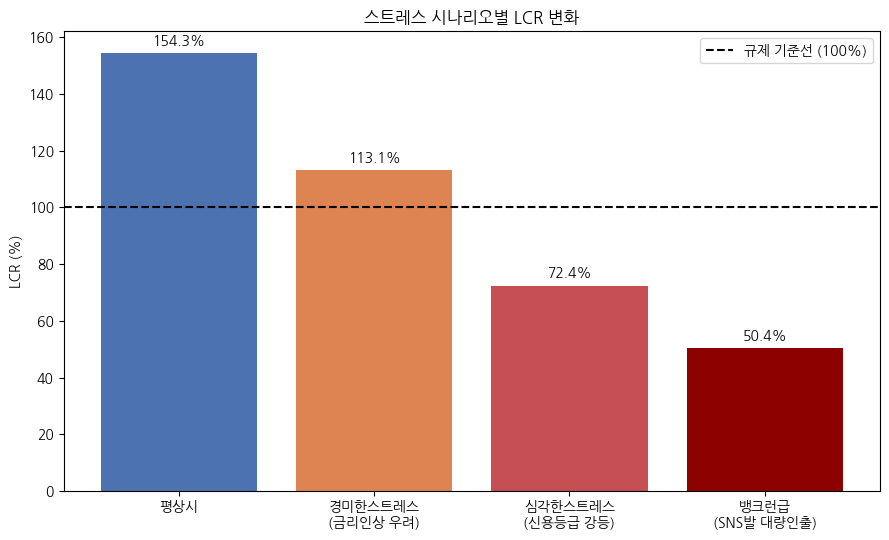

In [2]:
# ============================================================
# [Cell 2] 스트레스 시나리오별 LCR 변화 + NSFR 계산
# ============================================================

# ------------------------------------------------------------
# 1) 스트레스 시나리오별 유출률 정의
# ------------------------------------------------------------
# 위기가 심해질수록 예금이탈 속도(유출률)가 커짐 -> 특히 "불안정 예금"과
# "도매조달"이 위기 시 가장 먼저, 가장 크게 빠져나가는 항목
scenarios = {
    '평상시': normal_outflow_rates,
    '경미한스트레스\n(금리인상 우려)': {
        '개인예금_안정적(예금보호대상)': 0.07,
        '개인예금_불안정(고액/온라인전용)': 0.20,
        '기업예금': 0.35,
        '도매조달_콜머니등단기차입': 1.00,
        '자기자본및기타비유동성부채': 0.00
    },
    '심각한스트레스\n(신용등급 강등)': {
        '개인예금_안정적(예금보호대상)': 0.10,
        '개인예금_불안정(고액/온라인전용)': 0.40,
        '기업예금': 0.60,
        '도매조달_콜머니등단기차입': 1.00,
        '자기자본및기타비유동성부채': 0.00
    },
    '뱅크런급\n(SNS발 대량인출)': {
        '개인예금_안정적(예금보호대상)': 0.15,
        '개인예금_불안정(고액/온라인전용)': 0.70,   # 온라인전용예금은 앱으로 즉시 이체 가능해 위기 시 급격히 유출
        '기업예금': 0.80,
        '도매조달_콜머니등단기차입': 1.00,
        '자기자본및기타비유동성부채': 0.00
    }
}

# ------------------------------------------------------------
# 2) 시나리오별 LCR 계산
# ------------------------------------------------------------
scenario_results = []
for name, rates in scenarios.items():
    result = calculate_lcr(balance_sheet_assets, balance_sheet_liab, rates)
    result['시나리오'] = name
    scenario_results.append(result)

scenario_df = pd.DataFrame(scenario_results)[['시나리오', 'HQLA', '순유출액', 'LCR(%)']]
print("=== 시나리오별 LCR 비교 ===")
print(scenario_df.to_string(index=False))

# ------------------------------------------------------------
# 3) NSFR 계산 (장기 자금조달 안정성)
# ------------------------------------------------------------
def calculate_nsfr(assets, liabs):
    # ASF(가용안정자금): 자금조달원의 안정성에 따라 가중치 부여
    asf = (liabs['개인예금_안정적(예금보호대상)'] * 0.95 +   # 안정적 개인예금은 대부분 안정자금으로 인정
           liabs['개인예금_불안정(고액/온라인전용)'] * 0.90 +
           liabs['기업예금'] * 0.50 +
           liabs['도매조달_콜머니등단기차입'] * 0.00 +       # 단기조달은 안정자금으로 인정 안함
           liabs['자기자본및기타비유동성부채'] * 1.00)        # 자기자본은 완전히 안정적인 자금

    # RSF(필요안정자금): 자산의 유동화 난이도에 따라 가중치 부여
    rsf = (assets['HQLA_Level1_현금및국채'] * 0.05 +
           assets['HQLA_Level2A_우량회사채'] * 0.15 +
           assets['HQLA_Level2B_주식등'] * 0.50 +
           assets['대출자산_만기1개월내회수'] * 0.15 +
           assets['대출자산_기타'] * 0.85)                    # 장기대출은 유동화가 어려워 안정자금 필요도가 높음

    nsfr = asf / rsf * 100
    return {'ASF': asf, 'RSF': rsf, 'NSFR(%)': nsfr}

nsfr_result = calculate_nsfr(balance_sheet_assets, balance_sheet_liab)
print(f"\n=== NSFR 산출 결과 ===")
for k, v in nsfr_result.items():
    print(f"{k}: {v:,.1f}" + ("%" if k == 'NSFR(%)' else "억원"))
print(f"규제 기준(100%) 대비: {'충족' if nsfr_result['NSFR(%)'] >= 100 else '미충족'}")

# ------------------------------------------------------------
# 4) 시각화: 시나리오별 LCR 붕괴 추이
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ['#4C72B0', '#DD8452', '#C44E52', '#8C0000']
bars = ax.bar(scenario_df['시나리오'], scenario_df['LCR(%)'], color=colors)
ax.axhline(100, color='black', linestyle='--', lw=1.5, label='규제 기준선 (100%)')
for bar, val in zip(bars, scenario_df['LCR(%)']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 3, f'{val:.1f}%',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('LCR (%)')
ax.set_title('스트레스 시나리오별 LCR 변화')
ax.legend()
plt.tight_layout()
plt.show()